# 05 — Forecast first: every name, every day, scored before any trade

Notebooks 03 and 04 judged each agent by one trade a day: over 60 days that is 4 to 17 trades per agent, which cannot separate skill from luck. This notebook changes the question. Every day the forecaster is shown the same universe table as before and must state, **for each of the 50 names, the probability that it beats the equal-weight average of the 50 over the next 10 trading days**. Fifty forecasts a day, ~3,000 per window, scored directly:

- **rank IC** — Spearman correlation between the forecast and the realised excess return, per day; its mean and a Newey-West t-statistic (forecasts on overlapping horizons are autocorrelated, so the plain t-stat would flatter everyone)
- **hit rate** — of the names given more than 0.5, how many beat the average
- **Brier score** — mean squared error of the probability; 0.25 is what "0.5 for everything" scores, so anything above 0.25 is worse than saying nothing
- **calibration** — among names given ~0.7, did ~70% beat the average?
- **quintile spread** — realised excess return of the top fifth of names by forecast minus the bottom fifth, in return units

Only then is a portfolio built from the forecasts — mechanically, top-5 long and bottom-5 short, held 10 days, fees charged — so that signal quality and implementation can be told apart: *was the forecast bad, or was the trading of it bad?* This is how a desk evaluates any signal source.

Controls: 10-day momentum (rank of `ret_10d`), its reverse, random probabilities, and the constant 0.5. The last one matters: it is perfectly calibrated and has no information, and it sets the Brier floor.

In [1]:
import sys, json, time, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
logging.basicConfig(level=logging.WARNING, format="%(message)s")
pd.set_option("display.width", 180, "display.max_columns", 40)

from alphabench.universe import TICKERS, ALL_SYMBOLS, BENCHMARK
from alphabench.market import load_prices
from alphabench.agents import OllamaBackend
from alphabench.replay import decision_dates
from alphabench.metrics import equal_weight_index
from alphabench.forecast import (HORIZON, LLMForecaster, MomentumForecaster, RandomForecaster, ConstantForecaster,
                                 forward_targets, run_forecasts, load_forecasts, evaluate, scorecard, calibration_table,
                                 daily_ic, quintile_spread, forecast_portfolio, attribution, newey_west_tstat)

CACHE, LLM_CACHE = ROOT / "data" / "prices.parquet", ROOT / "data" / "llm_cache"
RESULTS = ROOT / "data" / "results" / "forecast_h10"
md = load_prices(ALL_SYMBOLS, "2023-09-01", None, CACHE)

# ---- the same fixed window as notebooks 03/04, so the two experiments describe the same summer
WINDOW_START, N_CYCLES = "2026-06-01", 60
dates = decision_dates(md, WINDOW_START)[:N_CYCLES]
targets = forward_targets(md, dates, HORIZON)
n_scored = int(targets["beat"].notna().any(axis=1).sum())
print(f"{len(dates)} forecast dates: {dates[0].date()} → {dates[-1].date()}  |  horizon {HORIZON} trading days  |  "
      f"{n_scored} dates have a complete target (prices end {md.last_date.date()})")
if n_scored < len(dates):
    print(f"→ {len(dates) - n_scored} dates cannot be scored yet: refresh prices with load_prices(..., refresh=True) once "
          f"{HORIZON} trading days have passed since {dates[-1].date()}.")

60 forecast dates: 2026-06-01 → 2026-08-25  |  horizon 10 trading days  |  58 dates have a complete target (prices end 2026-09-04)
→ 2 dates cannot be scored yet: refresh prices with load_prices(..., refresh=True) once 10 trading days have passed since 2026-08-25.


## 1. Controls (seconds)

Momentum and reversal turn a cross-sectional rank into probabilities between 0.2 and 0.8 — an ordering with modest confidence. Three random forecasters give a first feel for noise; section 5 draws the full null distribution.

In [2]:
controls = [MomentumForecaster("ret_10d"), MomentumForecaster("ret_10d", reverse=True),
            RandomForecaster(0), RandomForecaster(1), RandomForecaster(2), ConstantForecaster()]
fc_controls = run_forecasts(md, controls, dates, out_dir=RESULTS / "controls")
scorecard(fc_controls, targets).round(3)

,n_forecasts,n_dates_scored,n_dates_forecast,coverage,ic_mean,ic_std,ic_tstat_nw,ic_share_positive,hit_rate,n_decided,brier,brier_skill,spread_mean,spread_tstat_nw,p_mean,p_std,share_at_0.5,share_confident
forecaster,,,,,,,,,,,,,,,,,,
control_momentum_ret_10d,2900,58,60,1.0,-0.091,0.243,-1.592,0.362,0.480,2886,0.291,-0.165,-0.021,-1.917,0.500,0.177,0.005,0.356
control_reversal_ret_10d,2900,58,60,1.0,0.091,0.243,1.592,0.638,0.520,2886,0.271,-0.085,0.022,1.999,0.500,0.177,0.005,0.356
control_random_0,2900,58,60,1.0,0.017,0.146,1.421,0.517,0.517,2896,0.322,-0.287,0.002,0.673,0.498,0.289,0.001,0.597
control_random_1,2900,58,60,1.0,-0.054,0.139,-4.411,0.362,0.487,2895,0.340,-0.360,-0.008,-2.243,0.495,0.288,0.002,0.596
control_random_2,2900,58,60,1.0,-0.015,0.145,-0.680,0.483,0.499,2898,0.338,-0.354,-0.006,-1.334,0.504,0.291,0.001,0.613
control_constant_0.5,2900,0,60,1.0,NaN,NaN,NaN,NaN,NaN,0,0.250,0.000,NaN,NaN,0.500,0.000,1.000,0.000


## 2. The model (long — leave it running)

One call per day: the universe table for all 50 names plus SPY candles in (~8-10k tokens), a JSON list of 50 probabilities out. Ollama's structured output restricts symbols to the universe. A call that returns fewer than half the names is sent back once with the error; whatever comes back is kept and the missing names stay NaN (they are simply not scored). Cached after the first run.

In [3]:
backend = OllamaBackend(think=False)
MODEL = "qwen3:8b"
assert any(m.startswith(MODEL) for m in backend.list_models()), f"{MODEL} not pulled: ollama pull {MODEL}"

llm = LLMForecaster(f"{MODEL.replace(':', '-')}_fc_h{HORIZON}", backend, MODEL, horizon=HORIZON, cache_dir=LLM_CACHE)

def on_date(i, n, t, elapsed):
    r = llm.records[-1] if llm.records else None
    tag = "cached" if (r and r.cached) else f"{(r.latency_s if r else 0):.0f}s"
    print(f"  {i:3d}/{n} {t.date()}  {tag:>7}  names {r.n_valid if r else 0:2d}  elapsed {elapsed/60:4.0f} min  eta {(elapsed/i)*(n-i)/60:4.0f} min", flush=True)

fc_llm = run_forecasts(md, [llm], dates, out_dir=RESULTS / "llm", on_date=on_date)
forecasts = {**fc_llm, **fc_controls}
pd.Series(llm.stats()).to_frame("qwen3-8b").T

    1/60 2026-06-01      78s  names 50  elapsed    1 min  eta   77 min
    2/60 2026-06-02      73s  names 50  elapsed    3 min  eta   73 min
    3/60 2026-06-03      53s  names 49  elapsed    3 min  eta   65 min
    4/60 2026-06-04      45s  names 50  elapsed    4 min  eta   58 min
    5/60 2026-06-05      45s  names 50  elapsed    5 min  eta   54 min
    6/60 2026-06-08      49s  names 50  elapsed    6 min  eta   52 min
    7/60 2026-06-09      53s  names 50  elapsed    7 min  eta   50 min
    8/60 2026-06-10      51s  names 50  elapsed    7 min  eta   49 min
    9/60 2026-06-11      50s  names 50  elapsed    8 min  eta   47 min
   10/60 2026-06-12      51s  names 50  elapsed    9 min  eta   46 min
   11/60 2026-06-15      51s  names 47  elapsed   10 min  eta   45 min
   12/60 2026-06-16      52s  names 50  elapsed   11 min  eta   44 min
   13/60 2026-06-17      54s  names 50  elapsed   12 min  eta   43 min
   14/60 2026-06-18      56s  names 44  elapsed   13 min  eta   42 min
   15/

,calls,cached,repairs,invalid_final,avg_names_returned,prompt_tokens,completion_tokens,avg_prompt_tokens,avg_completion_tokens,avg_latency_s,cost_usd
qwen3-8b,60.0,0.0,0.0,0.0,49.35,332759.0,60154.0,5545.983333,1002.566667,99.470039,0.0


## 3. Scorecard

`ic_tstat_nw` is the number to read first: above ~2 in absolute value and the ordering is unlikely to be noise; the sign tells you whether the model ranks names the right way round or backwards. `brier_skill` is 1 − Brier/0.25: positive means better than saying 0.5 for everything, negative means worse. `share_at_0.5` and `share_confident` describe how the probabilities are used; a model that never leaves 0.5 has abstained, a model that is always confident is the notebook-04 finding again.

In [4]:
sc = scorecard(forecasts, targets)
sc.to_csv(RESULTS / "scorecard.csv")
cols = ["n_forecasts", "n_dates_scored", "coverage", "ic_mean", "ic_tstat_nw", "ic_share_positive", "hit_rate", "brier", "brier_skill",
        "spread_mean", "spread_tstat_nw", "p_mean", "p_std", "share_at_0.5", "share_confident"]
sc[cols].style.format({"coverage": "{:.0%}", "ic_mean": "{:+.3f}", "ic_tstat_nw": "{:+.2f}", "ic_share_positive": "{:.0%}", "hit_rate": "{:.1%}",
                       "brier": "{:.4f}", "brier_skill": "{:+.3f}", "spread_mean": "{:+.2%}", "spread_tstat_nw": "{:+.2f}",
                       "p_mean": "{:.3f}", "p_std": "{:.3f}", "share_at_0.5": "{:.0%}", "share_confident": "{:.0%}"}, na_rep="—")

,n_forecasts,n_dates_scored,coverage,ic_mean,ic_tstat_nw,ic_share_positive,hit_rate,brier,brier_skill,spread_mean,spread_tstat_nw,p_mean,p_std,share_at_0.5,share_confident
forecaster,,,,,,,,,,,,,,,
qwen3-8b_fc_h10,2861,58,99%,-0.060,-1.37,40%,48.2%,0.2638,-0.055,-1.87%,-1.77,0.469,0.095,6%,6%
control_momentum_ret_10d,2900,58,100%,-0.091,-1.59,36%,48.0%,0.2913,-0.165,-2.10%,-1.92,0.500,0.177,0%,36%
control_reversal_ret_10d,2900,58,100%,+0.091,+1.59,64%,52.0%,0.2711,-0.085,+2.16%,+2.00,0.500,0.177,0%,36%
control_random_0,2900,58,100%,+0.017,+1.42,52%,51.7%,0.3218,-0.287,+0.22%,+0.67,0.498,0.289,0%,60%
control_random_1,2900,58,100%,-0.054,-4.41,36%,48.7%,0.3400,-0.360,-0.77%,-2.24,0.495,0.288,0%,60%
control_random_2,2900,58,100%,-0.015,-0.68,48%,49.9%,0.3385,-0.354,-0.56%,-1.33,0.504,0.291,0%,61%
control_constant_0.5,2900,0,100%,—,—,—,—,0.2500,+0.000,—,—,0.500,0.000,100%,0%


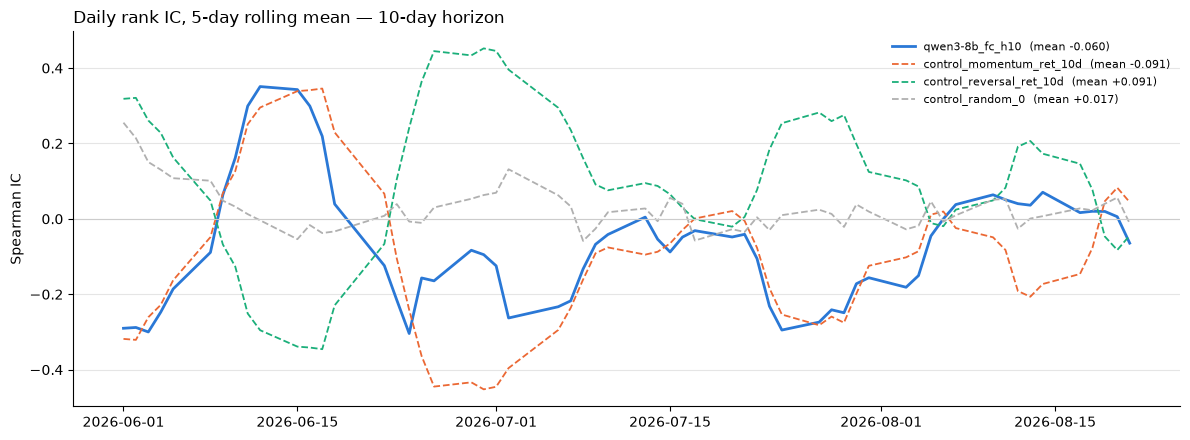

In [5]:
PALETTE = {"llm": "#2a78d6", "momentum": "#eb6834", "reversal": "#1baf7a", "random": "#b0b0b0", "constant": "#7a7a7a"}
def colour(name):
    for k, c in PALETTE.items():
        if k in name: return c
    return PALETTE["llm"]

fig, ax = plt.subplots(figsize=(12, 4.5))
for name, p in forecasts.items():
    if "random_1" in name or "random_2" in name or "constant" in name: continue
    ic = daily_ic(p, targets["excess"]).dropna()
    ax.plot(ic.index, ic.rolling(5, min_periods=1).mean(), lw=2 if "fc_" in name else 1.3, color=colour(name),
            ls="-" if "fc_" in name else "--", label=f"{name}  (mean {ic.mean():+.3f})")
ax.axhline(0, color="#ccc", lw=0.8)
ax.set_title(f"Daily rank IC, 5-day rolling mean — {HORIZON}-day horizon", loc="left"); ax.set_ylabel("Spearman IC")
ax.legend(frameon=False, fontsize=8); ax.grid(axis="y", color="#e5e5e5"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Calibration and how the probabilities are used

Left: stated probability against the realised beat rate, per bucket (the diagonal is perfect calibration; the constant control sits on it at 0.5 by definition). Right: the distribution of the probabilities the model wrote down.

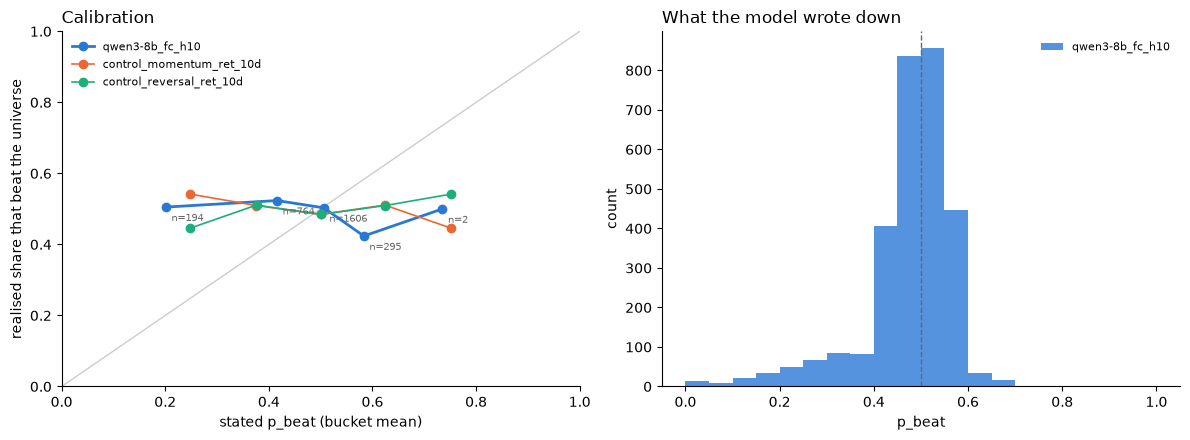

,n,stated,realised
p_beat bucket,,,
"(-0.001, 0.3]",194,0.201,0.505
"(0.3, 0.45]",764,0.416,0.524
"(0.45, 0.55]",1606,0.506,0.503
"(0.55, 0.7]",295,0.583,0.424
"(0.7, 1.0]",2,0.735,0.500


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot([0, 1], [0, 1], color="#ccc", lw=1)
for name, p in forecasts.items():
    if "random" in name or "constant" in name: continue
    cal = calibration_table(p, targets["beat"])
    a1.plot(cal["stated"], cal["realised"], "o-", color=colour(name), label=name, lw=2 if "fc_" in name else 1.2)
    for s, r, n in zip(cal["stated"], cal["realised"], cal["n"]):
        if "fc_" in name: a1.annotate(f"n={n}", (s, r), textcoords="offset points", xytext=(4, -10), fontsize=7, color="#666")
a1.set_xlabel("stated p_beat (bucket mean)"); a1.set_ylabel("realised share that beat the universe"); a1.set_xlim(0, 1); a1.set_ylim(0, 1)
a1.set_title("Calibration", loc="left"); a1.legend(frameon=False, fontsize=8); a1.spines[["top", "right"]].set_visible(False)
for name, p in fc_llm.items():
    a2.hist(p.stack(future_stack=True).dropna(), bins=np.linspace(0, 1, 21), color=colour(name), alpha=0.8, label=name)
a2.axvline(0.5, color="#666", lw=1, ls="--"); a2.set_xlabel("p_beat"); a2.set_ylabel("count"); a2.set_title("What the model wrote down", loc="left")
a2.legend(frameon=False, fontsize=8); a2.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
calibration_table(next(iter(fc_llm.values())), targets["beat"]).round(3)

## 5. Against a thousand random forecasters

The same 60 days, the same 50 names, probabilities drawn at random. Where does the model's mean IC, and its quintile spread, sit in that distribution? "Beat 95 in 100" is the bar for taking the ordering seriously.

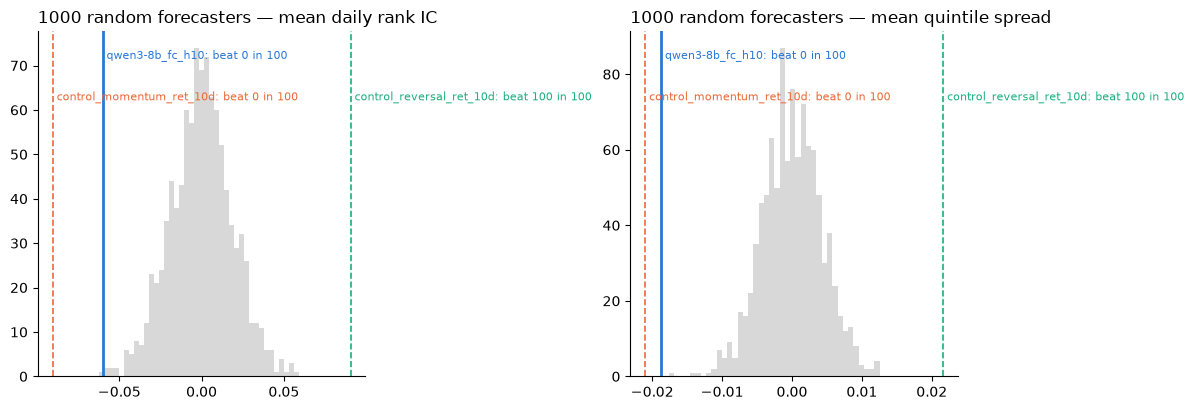

In [7]:
N_NULL = 1000
null_ic, null_spread = [], []
rng = np.random.default_rng(123)
for _ in range(N_NULL):
    r = pd.DataFrame(rng.uniform(0, 1, (len(dates), len(TICKERS))), index=dates, columns=TICKERS)
    null_ic.append(daily_ic(r, targets["excess"]).mean()); null_spread.append(quintile_spread(r, targets["excess"]).mean())
null_ic, null_spread = pd.Series(null_ic), pd.Series(null_spread)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, null, key, label in [(axes[0], null_ic, "ic_mean", "mean daily rank IC"), (axes[1], null_spread, "spread_mean", "mean quintile spread")]:
    ax.hist(null, bins=40, color="#d8d8d8")
    for name in forecasts:
        if "random" in name or "constant" in name: continue
        v = sc.loc[name, key]; pct = (null < v).mean() * 100
        ax.axvline(v, color=colour(name), lw=2 if "fc_" in name else 1.2, ls="-" if "fc_" in name else "--")
        ax.text(v, ax.get_ylim()[1] * (0.92 if "fc_" in name else 0.8), f" {name}: beat {pct:.0f} in 100", color=colour(name), fontsize=8)
    ax.set_title(f"{N_NULL} random forecasters — {label}", loc="left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 6. From forecast to portfolio — where does the P&L go?

The same forecasts, traded mechanically: each day the top 5 names by probability go long and the bottom 5 short, equal-weighted, entered at the next close and held 10 days; ten such cohorts run at once, each with a tenth of the capital; 0.1% per side on every entry and exit. No discretion, no sizing decisions, no stops — the only input is the ordering. Read the table left to right: forecast quality, then the gross return the ordering produced, then what fees left of it. A good spread with a poor net return is an implementation problem; a poor spread is a signal problem, and no trading rule will fix it.

In [8]:
first, last = dates[0], md.dates[min(md.dates.searchsorted(dates[-1]) + 1 + HORIZON, len(md.dates) - 1)]
ew = equal_weight_index(md.close[TICKERS], start=first).loc[:last]
attr = attribution(forecasts, targets, md, HORIZON, k=5, long_only=False, benchmark=ew)
attr.to_csv(RESULTS / "attribution.csv")
attr.style.format({"ic_mean": "{:+.3f}", "ic_tstat_nw": "{:+.2f}", "hit_rate": "{:.1%}", "brier": "{:.4f}", "spread_mean": "{:+.2%}", "spread_tstat_nw": "{:+.2f}",
                   "portfolio_gross": "{:+.1%}", "portfolio_net": "{:+.1%}", "sharpe_net": "{:.2f}", "max_drawdown_net": "{:+.1%}", "fees_pct": "{:.2%}",
                   "excess_vs_benchmark": "{:+.1%}"}, na_rep="—")

,ic_mean,ic_tstat_nw,hit_rate,brier,spread_mean,spread_tstat_nw,portfolio_gross,portfolio_net,sharpe_net,max_drawdown_net,fees_pct,n_cohorts,excess_vs_benchmark
forecaster,,,,,,,,,,,,,
qwen3-8b_fc_h10,-0.060,-1.37,48.2%,0.2638,-1.87%,-1.77,-14.8%,-16.9%,-3.45,-18.9%,2.40%,60,-22.6%
control_momentum_ret_10d,-0.091,-1.59,48.0%,0.2913,-2.10%,-1.92,-15.1%,-17.1%,-2.58,-21.0%,2.40%,60,-22.8%
control_reversal_ret_10d,+0.091,+1.59,52.0%,0.2711,+2.16%,+2.00,+15.5%,+12.8%,1.89,-9.4%,2.40%,60,+7.1%
control_random_0,+0.017,+1.42,51.7%,0.3218,+0.22%,+0.67,-0.7%,-3.1%,-1.83,-6.3%,2.40%,60,-8.8%
control_random_1,-0.054,-4.41,48.7%,0.3400,-0.77%,-2.24,-0.5%,-2.8%,-1.66,-3.4%,2.40%,60,-8.5%
control_random_2,-0.015,-0.68,49.9%,0.3385,-0.56%,-1.33,-4.6%,-6.9%,-3.95,-7.7%,2.40%,60,-12.6%
control_constant_0.5,—,—,—,0.2500,—,—,+0.0%,+0.0%,0.00,+0.0%,0.00%,0,-5.7%


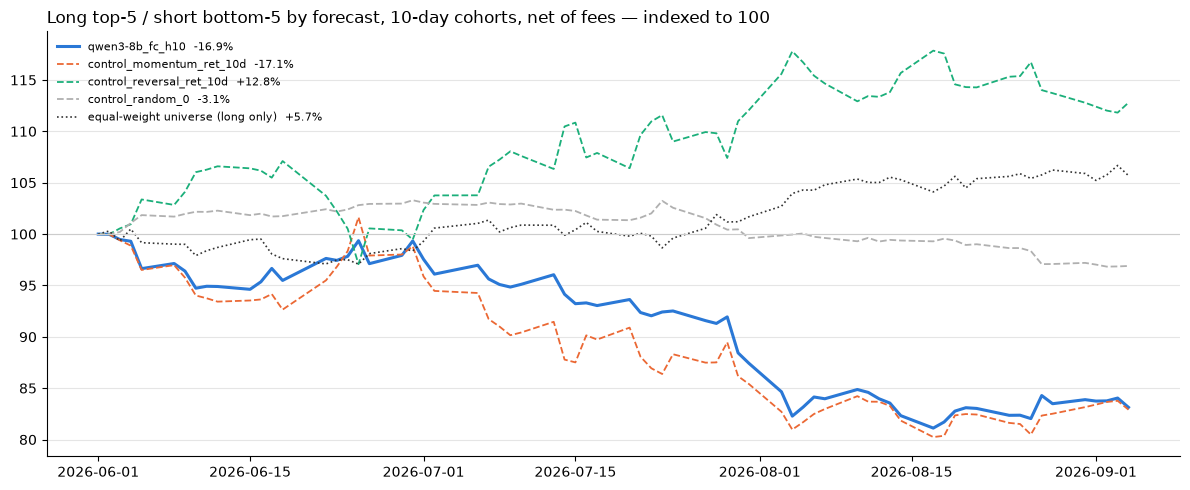

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, p in forecasts.items():
    if "random_1" in name or "random_2" in name or "constant" in name: continue
    pf = forecast_portfolio(p, md, HORIZON, k=5)
    eq = pf["equity"] / pf["equity"].iloc[0] * 100
    ax.plot(eq.index, eq, color=colour(name), lw=2.2 if "fc_" in name else 1.3, ls="-" if "fc_" in name else "--", label=f"{name}  {eq.iloc[-1]-100:+.1f}%")
ewi = ew / ew.iloc[0] * 100
ax.plot(ewi.index, ewi, color="#333", lw=1.2, ls=":", label=f"equal-weight universe (long only)  {ewi.iloc[-1]-100:+.1f}%")
ax.axhline(100, color="#ccc", lw=0.8)
ax.set_title("Long top-5 / short bottom-5 by forecast, 10-day cohorts, net of fees — indexed to 100", loc="left")
ax.legend(frameon=False, fontsize=8); ax.grid(axis="y", color="#e5e5e5"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 7. What was the model actually doing?

Before concluding, one check: how do the model's probabilities relate to the features it was shown? A daily Spearman correlation between `p_beat` and each column of the universe table says whether the ranking is the model's own or a copy of something in the table.

In [ ]:
from alphabench.prompt import build_base, universe_rows
FEATS = ["ret_1d", "ret_5d", "ret_10d", "ret_30d", "rsi_1d", "sma20_pct", "sma50_pct", "hi20_pct", "lo20_pct", "vol_ratio", "vol_30d_ann", "adv_20d_bn"]
rows = []
for name, p in fc_llm.items():
    cors = {f: [] for f in FEATS}
    for d in p.index:
        tab = pd.DataFrame(universe_rows(build_base(md.asof(d), d, candidates="universe"))).set_index("symbol")
        for f in FEATS:
            cors[f].append(p.loc[d].rank().corr(tab[f].astype(float).rank()))
    rows.append(pd.Series({f: np.nanmean(v) for f, v in cors.items()}, name=name))
feature_corr = pd.DataFrame(rows).T
feature_corr.round(3).style.format("{:+.3f}").set_caption("Mean daily Spearman correlation between the model's p_beat and each feature it was shown")

## 8. What this shows, and what it does not

**The model ranks names backwards, and not by chance.** Its mean daily rank IC over 58 scored days is −0.060. A thousand random forecasters on the same days and names produce mean ICs with a standard deviation of about 0.02; the model sits below every one of them, three standard deviations on the wrong side. The quintile spread says the same thing in return units: the fifth of names it liked most underperformed the fifth it liked least by 1.9% per 10 days, again below all 1,000 random forecasters. In notebook 03 the question was whether a handful of losing trades meant anything; here the answer is that the ranking behind them was systematically inverted.

**It is a momentum proxy.** Section 7 explains why. The model's daily ordering correlates at 0.66 to 0.70 with `sma20_pct`, `rsi_1d` and `ret_10d`, the trend columns of the table it was shown. It reads what has gone up and says it will keep going up. This summer that was the losing bet: the plain 10-day momentum control scored an IC of −0.09 and its reverse +0.09, and the model landed between momentum and random, which is exactly what a noisy copy of momentum looks like. It contributed no information of its own; it borrowed momentum's and diluted it.

**Its probabilities are not probabilities.** Told it would be scored on calibration, the model became timid rather than calibrated: 94% of its values lie between 0.3 and 0.7, the standard deviation is 0.095, only 6% are more than 0.2 from a coin flip, and the mean is 0.469, below the 0.5 the prompt said to expect. The calibration curve is flat at about 0.5 in every bucket; the one bucket where it leaned (stated 0.58, n = 295) realised 0.42. Brier 0.264 against the 0.25 floor: worse than writing 0.5 for everything. Notebook 04 found a constant 0.85 on 50 trades; this is the same finding on 2,861 forecasts, with the sign flipped by the prompt. The model's confidence follows the instructions, not the data.

**The notebook 03 losses were the signal, not the trading.** A mechanical portfolio built from these forecasts (top 5 long, bottom 5 short, 10-day cohorts) lost 14.8% gross and 16.9% net, almost identical to the momentum control (−15.1% and −17.1%). Fees explain 2.4 points; the ranking explains the rest. No sizing rule, stop or prompt discipline would have rescued a book built on an inverted ordering.

**What it does not show.** One summer in which momentum reversed is a regime, not a verdict. The same model would have looked good in a trending quarter for the same bad reason. The claim that should survive any window is the narrower one: *this model's ranking is a momentum proxy carrying no information of its own*; in a second window that would show up as an IC near zero rather than below it. It is also one 8B model and one prompt; a larger model, or a prompt that hides the trend columns, could behave differently, and the harness now measures that in an afternoon. Two technical notes: the Newey-West t-statistics can overstate significance when the sampled autocorrelation of daily ICs happens to be negative (`control_random_1` shows −4.4 by chance), so the percentile against the random forecasters is the number to quote; and two of the sixty dates await 10 more trading days of prices before they can be scored.

**Next.** Anonymise the tickers and drop the trend columns, to see whether the model has any view at all once it cannot copy momentum; run the same 60 days with several seeds at temperature 0.7, to see whether the ranking is stable or a draw; and a second, trending window, to separate "momentum proxy" from "wrong this summer".